In [30]:
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output

class ExpVis:
    def __init__(self, exp_dir, cell_size):
        self.exp_dir = exp_dir
        self.cell_size = cell_size
        image_dirs = [d for d in self.exp_dir.glob("*") if d.is_dir()]
        self.combos = [
            (i / "image.jpg", i / "overlay.jpg", i / "mask.png")
            for i in image_dirs
        ]
        self.idx = 0

        self._show_overlay = True
        self._show_grid = False
        self._current = None

    def next_data(self):
        if self.idx >= len(self.combos):
            return None
        (img, overlay, mask) = self.combos[self.idx]
        (img, overlay, mask) = (plt.imread(img), plt.imread(overlay), plt.imread(mask))
        self.idx += 1
        return (img, overlay, mask)

    def draw_grid(self, ax, img_shape, cell_size, color="white", lw=0.5, alpha=0.5):
        h, w = img_shape[:2]
        ax.set_xticks(np.arange(0, w, cell_size), minor=True)
        ax.set_yticks(np.arange(0, h, cell_size), minor=True)

        # vertical lines
        for x in range(0, w, cell_size):
            ax.axvline(x, color=color, lw=lw, alpha=alpha)

        # horizontal lines
        for y in range(0, h, cell_size):
            ax.axhline(y, color=color, lw=lw, alpha=alpha)

    def show_widget_ui(self):
        toggle_btn = widgets.ToggleButton(
            value=True,
            description="Show Overlay",
            button_style="",
        )

        next_btn = widgets.Button(
            description="Next",
            button_style="primary",
        )

        show_grid_btn = widgets.ToggleButton(
            value=True,
            description="Show Grid",
            button_style="",
        )

        out = widgets.Output()

        def redraw():
            with out:
                clear_output(wait=True)

                if self._current is None:
                    print("No data")
                    return

                orig, overlay, mask = self._current

                fig, axs = plt.subplots(1, 1, figsize=(16, 8))

                # left plot
                if self._show_overlay:
                    axs.imshow(overlay)
                    axs.set_title("Overlayed Image")
                else:
                    axs.imshow(orig)
                    axs.set_title("Original Image")
                
                if self._show_grid:
                    self.draw_grid(axs, orig.shape, self.cell_size)

                # # right plot
                # axs[1].imshow(mask, cmap="gray")
                # axs[1].set_title("Mask")


                plt.tight_layout()
                plt.show()

        def on_toggle(change):
            self._show_overlay = change["new"]
            redraw()
        
        def on_grid_toggle(change):
            self._show_grid = change["new"]
            print("hellooooooo", self._show_grid)
            redraw()

        def on_next(_):
            data = self.next_data()
            if data is None:
                with out:
                    clear_output()
                    print("End of images")
                return
            self._current = data
            redraw()

        toggle_btn.observe(on_toggle, names="value")
        show_grid_btn.observe(on_grid_toggle, names="value")
        next_btn.on_click(on_next)

        controls = widgets.HBox([toggle_btn, show_grid_btn, next_btn])
        display(controls, out)

        on_next(None)


In [36]:
ev.combos[ev.idx-1][0]

PosixPath('/Users/hariomnarang/Desktop/personal/roads/datasets/test-pos-samples/stridded_mapillary_neg_with_elev/scale=50_to_50/269626184842101/image.jpg')

In [ ]:
from pathlib import Path

ev = ExpVis(Path("/Users/hariomnarang/Desktop/personal/roads/datasets/test-pos-samples/stridded_mapillary_neg_with_elev/scale=50_to_50"), 50)
ev.show_widget_ui()

Output()

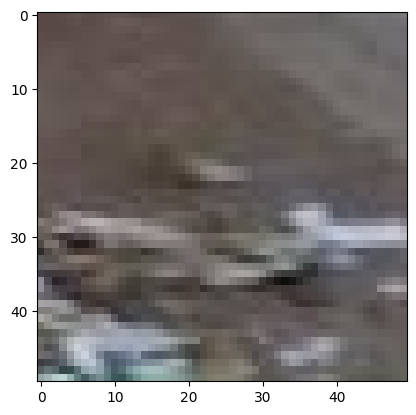

In [39]:
img = plt.imread('/Users/hariomnarang/Desktop/personal/roads/datasets/test-pos-samples/stridded_mapillary_neg_with_elev/scale=50_to_50/269626184842101/image.jpg')
plt.imshow(img[400:450, 650:700])